## **Global-Benchmark-Trial**

What if a model could explain itself? In this notebook, you leave the world of numeric prediction behind and build your first classifier — a Decision Tree that sorts countries into population tiers by asking a series of simple yes-or-no questions. Along the way, you'll confront one of machine learning's central tensions: the deeper a tree grows, the better it memorizes — and the worse it generalizes. Before Maji Ndogo's farmers can trust an algorithm with their fields, you need to prove it works on ground where the stakes are low and the patterns are known. That proving ground starts here.

## **Data Dictionary**

The World Population dataset contains country-level population and area statistics.

| Column | Description | Type |
|---|---|---|
| `Rank` | Global population rank | Int |
| `CCA3` | Three-letter country code | String |
| `Country/Territory` | Full country name | String |
| `Capital` | Capital city name | String |
| `Continent` | Continent | String |
| `2022 Population` | Population in 2022 | Int |
| `2020 Population` | Population in 2020 | Int |
| `2015 Population` | Population in 2015 | Int |
| `2010 Population` | Population in 2010 | Int |
| `2000 Population` | Population in 2000 | Int |
| `1990 Population` | Population in 1990 | Int |
| `1980 Population` | Population in 1980 | Int |
| `1970 Population` | Population in 1970 | Int |
| `Area (km²)` | Total land area in square kilometers | Float |
| `Density (per km²)` | Population density per square kilometer | Float |
| `Growth Rate` | Annual population growth rate | Float |
| `World Population Percentage` | Share of global population (%) | Float |

**Engineered target:** `Pop_class` — classifies each country as `Low`, `Medium`, or `High` based on its 2022 population using tertile thresholds.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

## **Data Preparation**

Before modeling, we engineer the target variable and select our feature set.

**Target engineering:** The 2022 population is divided into three classes using tertile thresholds:
- `Low`: Below the 33rd percentile.
- `Medium`: Between the 33rd and 66th percentiles.
- `High`: Above the 66th percentile.

**Features:** Historical population figures (1970–2020), land area, population density, growth rate, and world population share.


In [2]:
file_path = '../data/world_population.csv'
df_raw = pd.read_csv(file_path)

print(df_raw.shape)
display(df_raw.head())

(234, 17)


,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,1,PCE,Quengale,Tolmoor,Africa,1389119955,1391297088,1330390649,1260399724,1171458553,1040218459,964330509,778632584,1.579100e+07,87.969091,0.969401,4.565525
1,2,NJE,Renwick,Nirgora,Africa,1290091778,1263570456,1221328861,1186974799,1074627758,988895621,878835534,779055694,5.339974e+06,241.591385,0.951308,4.240056
2,3,LGO,Sillyn,Kaport,Europe,1264361636,1260868371,1185126035,1151863124,1015803190,940457159,863699023,744796131,9.170425e+06,137.873830,1.023436,4.155490
3,4,RRV,Caswick,Caslyn,Asia,1208541364,1164705056,1115776978,1104653139,996751161,903945568,827460985,715339367,1.371024e+07,88.148791,1.042949,3.972029
4,5,LMK,Bodale,Lusgora,Europe,1111430440,1076345401,1052929406,974978085,950847838,852902238,763724812,649746758,1.585367e+07,70.105544,1.026015,3.652862


In [3]:
def prepare_population_classification(LabelEncoder, df_raw):
    thresholds = df_raw['2022 Population'].quantile([1/3, 2/3])

    def classify_population(pop, low_thresh, high_thresh):
        if pop < low_thresh:
            return 'Low'
        elif pop < high_thresh:
            return 'Medium'
        else:
            return 'High'

    df_raw['Pop_class'] = df_raw['2022 Population'].apply(
        classify_population,
        low_thresh=thresholds[1/3],
        high_thresh=thresholds[2/3]
    )

    feature_cols = [
        '1970 Population', '1980 Population', '1990 Population',
        '2000 Population', '2010 Population', '2015 Population',
        '2020 Population', 'Area (km²)', 'Density (per km²)',
        'Growth Rate', 'World Population Percentage'
    ]

    df = df_raw[feature_cols + ['Pop_class']].dropna().copy()

    le = LabelEncoder()
    df['Pop_class_encoded'] = le.fit_transform(df['Pop_class'])

    print('Class distribution:')
    print(df['Pop_class'].value_counts())
    print(f'\nDataFrame shape: {df.shape}')
    print(f'Class labels: {list(le.classes_)}')
    return df, feature_cols, le

In [4]:
df, feature_cols, le = prepare_population_classification(
    LabelEncoder,
    df_raw
)

Class distribution:
Pop_class
High      78
Medium    78
Low       78
Name: count, dtype: int64

DataFrame shape: (234, 13)
Class labels: ['High', 'Low', 'Medium']


In [5]:
display(df.head())


,1970 Population,1980 Population,1990 Population,2000 Population,2010 Population,2015 Population,2020 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage,Pop_class,Pop_class_encoded
0,778632584,964330509,1040218459,1171458553,1260399724,1330390649,1391297088,1.579100e+07,87.969091,0.969401,4.565525,High,0
1,779055694,878835534,988895621,1074627758,1186974799,1221328861,1263570456,5.339974e+06,241.591385,0.951308,4.240056,High,0
2,744796131,863699023,940457159,1015803190,1151863124,1185126035,1260868371,9.170425e+06,137.873830,1.023436,4.155490,High,0
3,715339367,827460985,903945568,996751161,1104653139,1115776978,1164705056,1.371024e+07,88.148791,1.042949,3.972029,High,0
4,649746758,763724812,852902238,950847838,974978085,1052929406,1076345401,1.585367e+07,70.105544,1.026015,3.652862,High,0


## __Challenge 1: Training a Decision Tree Classifier__

We have features and a target. Time to build our first classifier.

A Decision Tree makes predictions by learning a series of if-else rules from the training data. At each split, it chooses the feature and threshold that best separates the classes — minimizing **Gini impurity** (or entropy). This is the classification analog of minimizing mean squared error in regression trees.

### __Task__
Create a function named `train_decision_tree` that:
- Takes a DataFrame, the list of feature columns, the encoded target column name, a `max_depth` parameter (default `3`), and `random_state` (default `42`).
- Splits the data 80-20 using the given `random_state`.
- Trains a `DecisionTreeClassifier` with the given `max_depth` on the training set.
- Returns `(model, X_test, y_test)`.

**Note:**
- Use `DecisionTreeClassifier` from `sklearn.tree`.
- Return format: `(model, X_test, y_test)`.

In [6]:
print(feature_cols)

['1970 Population', '1980 Population', '1990 Population', '2000 Population', '2010 Population', '2015 Population', '2020 Population', 'Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Population Percentage']


In [7]:
def train_decision_tree(
    df,
    feature_cols,
    target_col,
    max_depth=3,
    random_state=42
):
    """Train a Decision Tree Classifier and return the model and test data."""

    # Define features and target
    X = df[feature_cols]
    y = df[target_col]

    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state
    )

    # Train Decision Tree Classifier
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=random_state
    )

    model.fit(X_train, y_train)

    return model, X_test, y_test

In [8]:
model, X_test, y_test = train_decision_tree(
    df=df,
    feature_cols=feature_cols,
    target_col="Pop_class_encoded"
)

print(f"Model max_depth: {model.max_depth}")
print(f"Test set size: {len(X_test)}")
print(f"Number of leaves: {model.get_n_leaves()}")

Model max_depth: 3
Test set size: 47
Number of leaves: 3


## **Challenge 2: Visualizing the Tree**

One of the most powerful features of Decision Trees is their interpretability. Unlike regression coefficients that require domain expertise to interpret, we can literally **draw** a Decision Tree and trace how it reaches any prediction.

### **Task**
Create a function named `visualize_tree` that:
- Takes the fitted model, the list of feature column names, and the list of class names.
- Plots the decision tree using `sklearn.tree.plot_tree` with `filled=True` and `rounded=True`.
- Uses `plt.figure(figsize=(20, 8))` for readability.
- Adds a descriptive title.
- Returns the total number of nodes in the tree (`model.tree_.node_count`).

**Note:** The number of nodes includes both decision nodes and leaf nodes.

In [9]:
def visualize_tree(model, feature_cols, class_names):
    """Plot a fitted Decision Tree Classifier and return its node count."""

    plt.figure(figsize=(20, 8))

    plot_tree(
        model,
        feature_names=feature_cols,
        class_names=class_names,
        filled=True,
        rounded=True
    )

    plt.title("Decision Tree Classifier")
    plt.show()

    return model.tree_.node_count

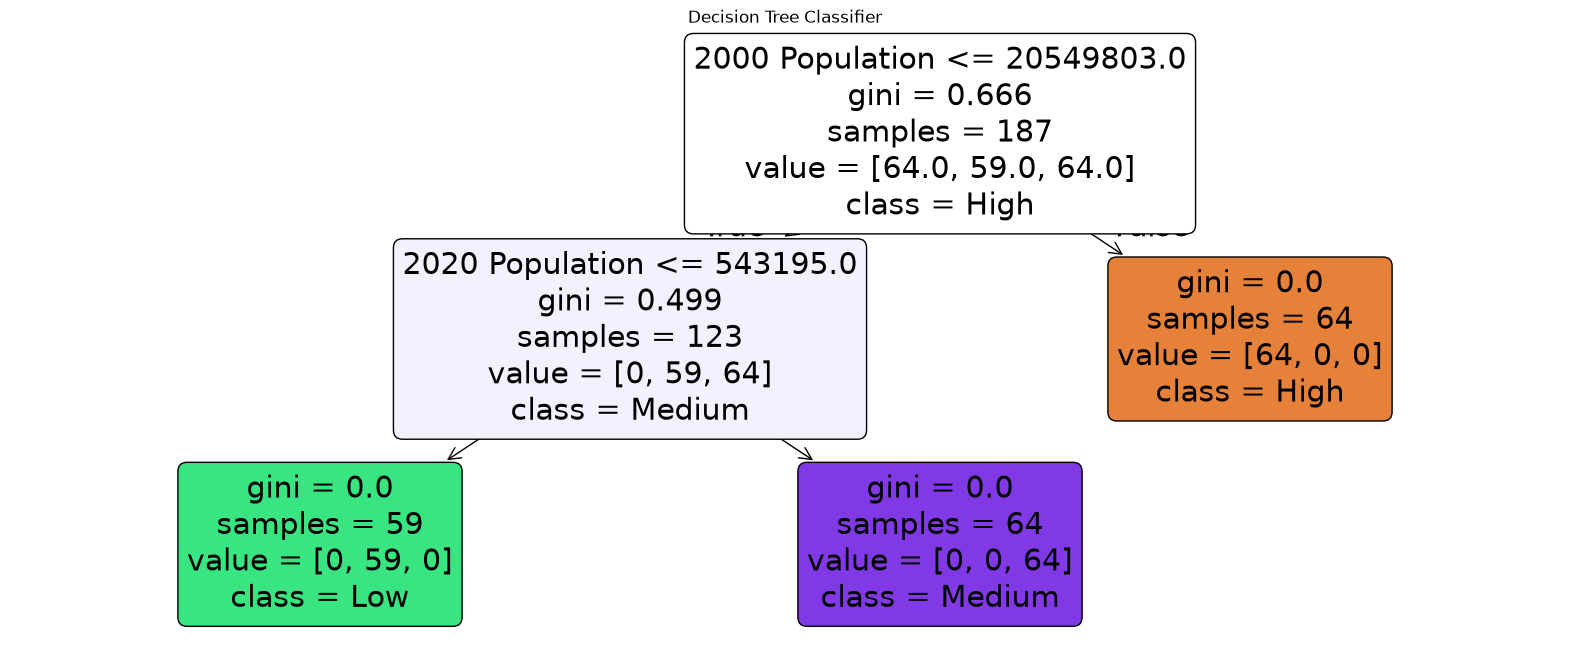

Total nodes in tree: 5


In [10]:
node_count = visualize_tree(
    model,
    feature_cols,
    le.classes_
)

print(f"Total nodes in tree: {node_count}")

## **Challenge 3: Evaluating the Classifier**

A diagram is useful for interpretation, but decisions need numbers. We will use **accuracy** — the proportion of test samples correctly classified — and the **classification report**, which breaks performance down by class with precision, recall, and F1-score.

### **Task**
Create a function named `evaluate_tree_classifier` that:
- Takes the fitted model, `X_test`, `y_test`, and the `LabelEncoder` object `le`.
- Generates predictions on the test set.
- Uses `le.inverse_transform` to convert encoded predictions and labels back to readable class names.
- Prints the full classification report.
- Returns overall accuracy as a float.

**Note:**
- Use `accuracy_score` and `classification_report` from `sklearn.metrics`.
- Return format: `float` (accuracy only).


In [11]:
def evaluate_tree_classifier(model, X_test, y_test, le):
    """Evaluate a fitted Decision Tree Classifier."""

    # Generate predictions
    y_pred = model.predict(X_test)

    # Convert encoded values back to class names
    y_test_labels = le.inverse_transform(y_test)
    y_pred_labels = le.inverse_transform(y_pred)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_labels, y_pred_labels)

    # Print classification report
    print(classification_report(y_test_labels, y_pred_labels))

    # Print overall accuracy
    print(f"Overall accuracy: {accuracy:.4f}")

    return float(accuracy)

In [12]:
accuracy = evaluate_tree_classifier(
    model,
    X_test,
    y_test,
    le
)

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        14
         Low       1.00      1.00      1.00        19
      Medium       1.00      1.00      1.00        14

    accuracy                           1.00        47
   macro avg       1.00      1.00      1.00        47
weighted avg       1.00      1.00      1.00        47

Overall accuracy: 1.0000


## **Challenge 4: The Effect of Tree Depth — Bias-Variance in Classification**

The bias-variance tradeoff applies to classification just as it does to regression. A shallow tree underfits (high bias — it cannot capture the true patterns). A very deep tree overfits (high variance — it memorizes the training data, including noise, and fails to generalize).

Plotting training and test accuracy against `max_depth` makes this tradeoff visible: training accuracy rises monotonically, while test accuracy peaks and then plateaus or drops.

### **Task**
Create a function named `depth_vs_accuracy` that:
- Takes the DataFrame, feature columns, encoded target column, and a list of depths to test.
- For each depth, trains a `DecisionTreeClassifier` (80-20 split, `random_state=42`) and records both training and test accuracy.
- Plots both curves on the same figure with a legend, axis labels, and title.
- Returns a DataFrame with columns `depth`, `train_accuracy`, and `test_accuracy`.

    

In [13]:
def depth_vs_accuracy(df, feature_cols, target_col, depths):
    """Evaluate Decision Tree accuracy across different tree depths."""

    results = []

    # Define features and target
    X = df[feature_cols]
    y = df[target_col]

    # Fixed 80-20 split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Train a tree for each depth
    for depth in depths:

        model = DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        )

        model.fit(X_train, y_train)

        # Predictions
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        # Accuracy
        train_accuracy = accuracy_score(y_train, train_pred)
        test_accuracy = accuracy_score(y_test, test_pred)

        results.append({
            "depth": depth,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy
        })

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)

    # Plot accuracy curves
    plt.figure(figsize=(9, 5))

    plt.plot(
        results_df["depth"],
        results_df["train_accuracy"],
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        results_df["depth"],
        results_df["test_accuracy"],
        marker="o",
        label="Test Accuracy"
    )

    plt.xlabel("Maximum Tree Depth")
    plt.ylabel("Accuracy")
    plt.title("Decision Tree Depth vs Classification Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df

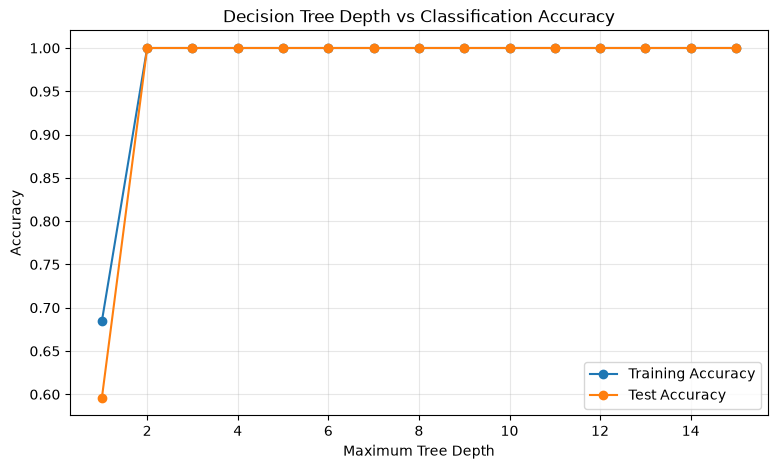

,depth,train_accuracy,test_accuracy
0,1,0.684492,0.595745
1,2,1.000000,1.000000
2,3,1.000000,1.000000
3,4,1.000000,1.000000
4,5,1.000000,1.000000
5,6,1.000000,1.000000
6,7,1.000000,1.000000
7,8,1.000000,1.000000
8,9,1.000000,1.000000
9,10,1.000000,1.000000


In [14]:
depth_results = depth_vs_accuracy(
    df,
    feature_cols,
    "Pop_class_encoded",
    depths=range(1, 16)
)

depth_results

In [15]:
print(type(df))
print(type(feature_cols))
print(type(le))
print(type(depth_results))
print(depth_results.head())

<class 'pandas.DataFrame'>
<class 'list'>
<class 'sklearn.preprocessing._label.LabelEncoder'>
<class 'pandas.DataFrame'>
   depth  train_accuracy  test_accuracy
0      1        0.684492       0.595745
1      2        1.000000       1.000000
2      3        1.000000       1.000000
3      4        1.000000       1.000000
4      5        1.000000       1.000000


## __Challenge 5: Pruning Validation — Finding the Optimal `max_depth`__

Challenge 4 showed us the tradeoff visually. Now we formalize it: identify the `max_depth` that maximizes test accuracy and train the final benchmark model at that depth.

### __Task__
Create a function named `find_optimal_depth` that:
- Takes the results DataFrame from Challenge 4, the modeling DataFrame, feature columns, target column, and `random_state` (default `42`).
- Identifies the `max_depth` with the highest `test_accuracy`.
- If multiple depths tie, selects the shallowest (simpler models are preferred when performance is equal).
- Trains a final `DecisionTreeClassifier` at the optimal depth on an 80-20 split with the given `random_state`.
- Returns `(optimal_depth, final_model)`.

In [16]:
def find_optimal_depth(
    results_df,
    df,
    feature_cols,
    target_col,
    random_state=42
):
    """Find the optimal tree depth and train the final classifier."""

    # Find the highest test accuracy
    best_accuracy = results_df["test_accuracy"].max()

    # Select the shallowest depth among ties
    optimal_depth = (
        results_df[
            results_df["test_accuracy"] == best_accuracy
        ]["depth"]
        .min()
    )

    # Define features and target
    X = df[feature_cols]
    y = df[target_col]

    # 80-20 train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state
    )

    # Train final model
    final_model = DecisionTreeClassifier(
        max_depth=optimal_depth,
        random_state=random_state
    )

    final_model.fit(X_train, y_train)

    return optimal_depth, final_model

In [17]:
optimal_depth, final_model = find_optimal_depth(
    depth_results,
    df,
    feature_cols,
    "Pop_class_encoded"
)

In [18]:
print(f"Optimal max_depth: {optimal_depth}")
print(f"Number of leaves in final model: {final_model.get_n_leaves()}")

Optimal max_depth: 2
Number of leaves in final model: 3



### **Why `.min()` is important**

This part handles the tie-breaking requirement:

```python 
optimal_depth = (
    results_df[
        results_df["test_accuracy"] == best_accuracy
    ]["depth"]
    .min()
)
```

Suppose your results were:

| depth | test_accuracy |
| ----: | ------------: |
|     2 |          1.00 |
|     3 |          1.00 |
|     4 |          1.00 |
|     5 |          1.00 |

All four have the same performance, so `.min()` selects **depth 2**, the simplest model.

This is a good model-selection principle: **when predictive performance is equal, prefer the simpler model.**
